In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [8]:
from sklearn.datasets import load_diabetes

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [10]:


data=load_diabetes()

In [11]:
df=pd.DataFrame(data.data , columns=data.feature_names)

In [12]:
df["target"]=data.target

In [13]:
print(df.head())

        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  


In [14]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB
None


In [15]:
print(df.isnull().sum())

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64


In [16]:
print(df.duplicated().sum())

0


In [17]:
print(df.describe())

                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
min   -1.072256e-01 -4.464164e-02 -9.027530e-02 -1.123988e-01 -1.267807e-01   
25%   -3.729927e-02 -4.464164e-02 -3.422907e-02 -3.665608e-02 -3.424784e-02   
50%    5.383060e-03 -4.464164e-02 -7.283766e-03 -5.670422e-03 -4.320866e-03   
75%    3.807591e-02  5.068012e-02  3.124802e-02  3.564379e-02  2.835801e-02   
max    1.107267e-01  5.068012e-02  1.705552e-01  1.320436e-01  1.539137e-01   

                 s2            s3            s4            s5            s6  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean   3.918434e-17 -5.777179e-18 -9.042540e-18  9.293722e-17  1.130318e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.

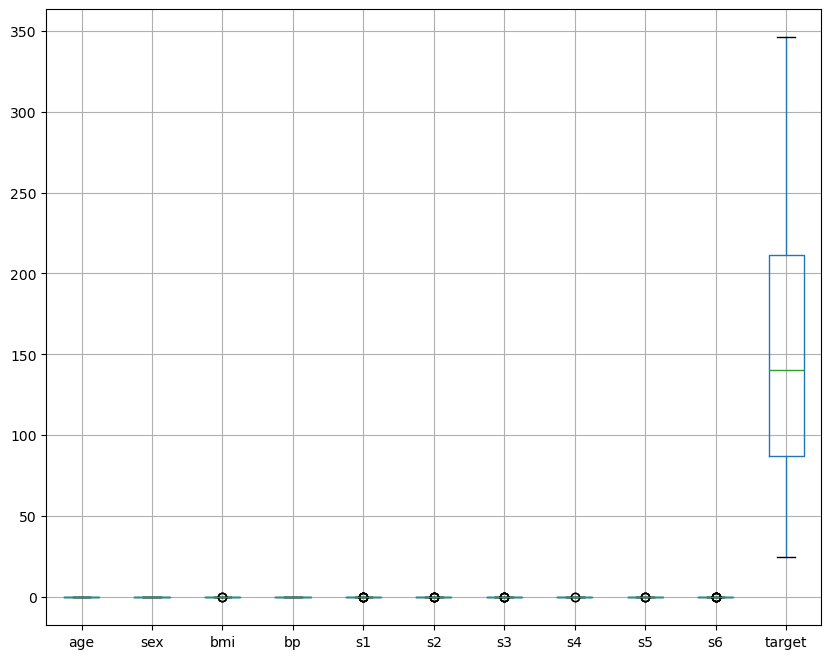

In [18]:
df.boxplot(figsize=(10,8))
plt.show()

In [19]:
corr=df.corr()


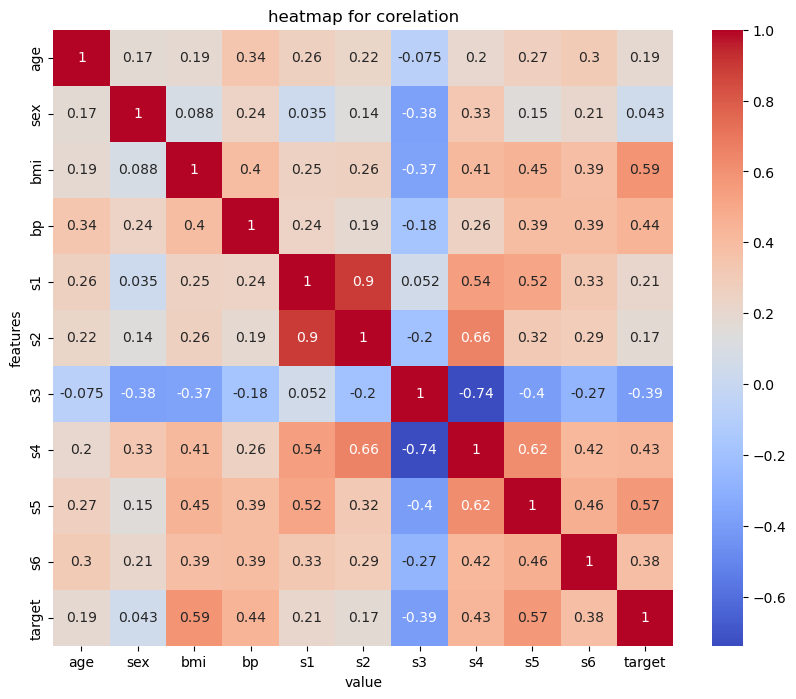

In [20]:


plt.figure(figsize=(10,8))
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.xlabel("value")
plt.ylabel("features")
plt.title("heatmap for corelation")
plt.show()

In [21]:
x=df.drop("target", axis=1)
y=df["target"]


In [22]:
X_train,X_test,Y_train,Y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [23]:
model=DecisionTreeRegressor()

In [24]:
model.fit(X_train,Y_train)


,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [27]:
Y_pred=model.predict(X_test)
mae=mean_absolute_error(Y_test,Y_pred)
mse=mean_squared_error(Y_test,Y_pred)
rmse=np.sqrt(mse)
r2score=r2_score(Y_test,Y_pred)
print(mae)
print(mse)
print(rmse)
print(r2score)


56.57303370786517
5024.752808988764
70.88549082138576
0.051602700810595814


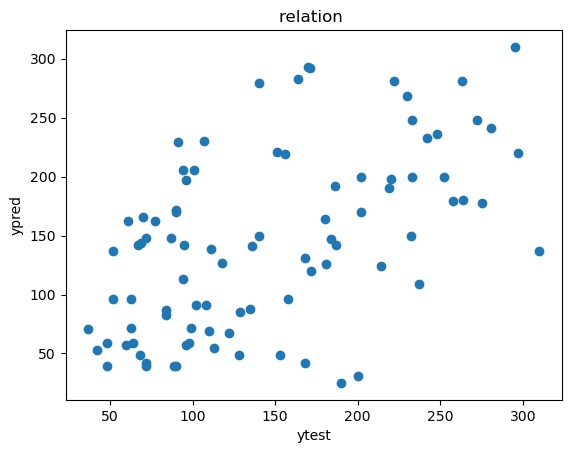

In [26]:
plt.scatter(Y_test,Y_pred)
plt.xlabel("ytest")
plt.ylabel("ypred")
plt.title("relation ")
plt.show()

In [29]:
residuals = Y_test - Y_pred


In [30]:
print(residuals)

287     29.0
211    -96.0
72      32.0
321    -38.0
73     -28.0
       ...  
255    104.0
90      39.0
57     -34.0
391     -9.0
24      37.0
Name: target, Length: 89, dtype: float64


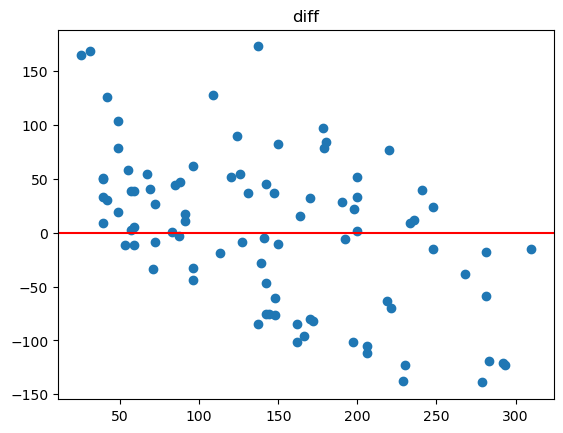

In [31]:
plt.scatter(Y_pred,residuals)
plt.title("diff")
plt.axhline(y=0,color='r')
plt.show()

In [32]:
print(df.columns)

Index(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6',
       'target'],
      dtype='object')


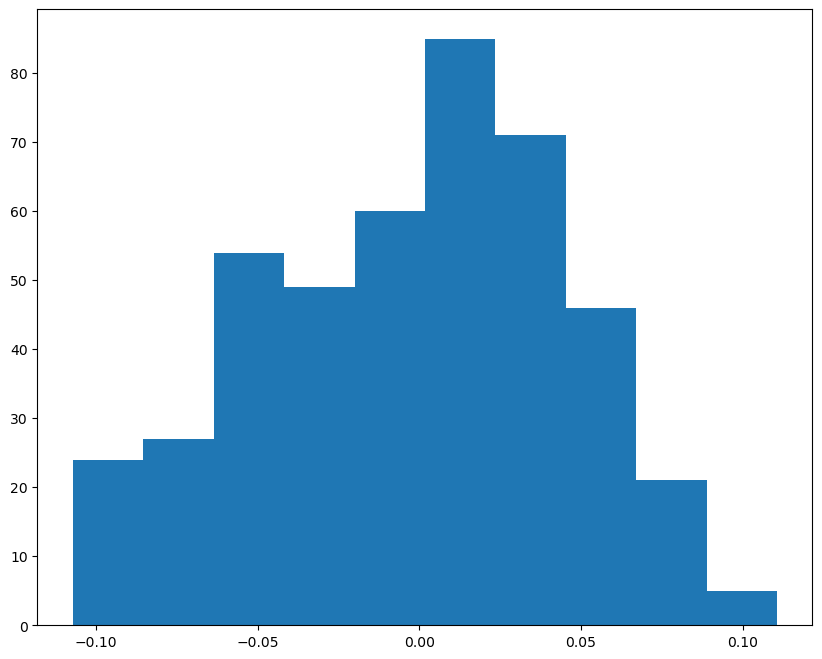

In [33]:
plt.figure(figsize=(10,8))
plt.hist(df["age"],bins=10)
plt.show()

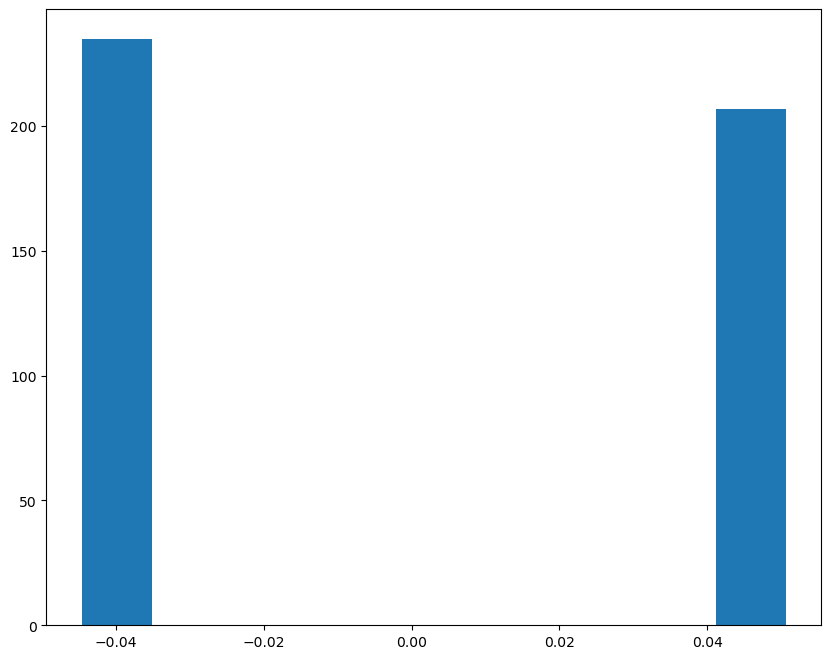

In [34]:
plt.figure(figsize=(10,8))
plt.hist(df["sex"],bins=10)
plt.show()

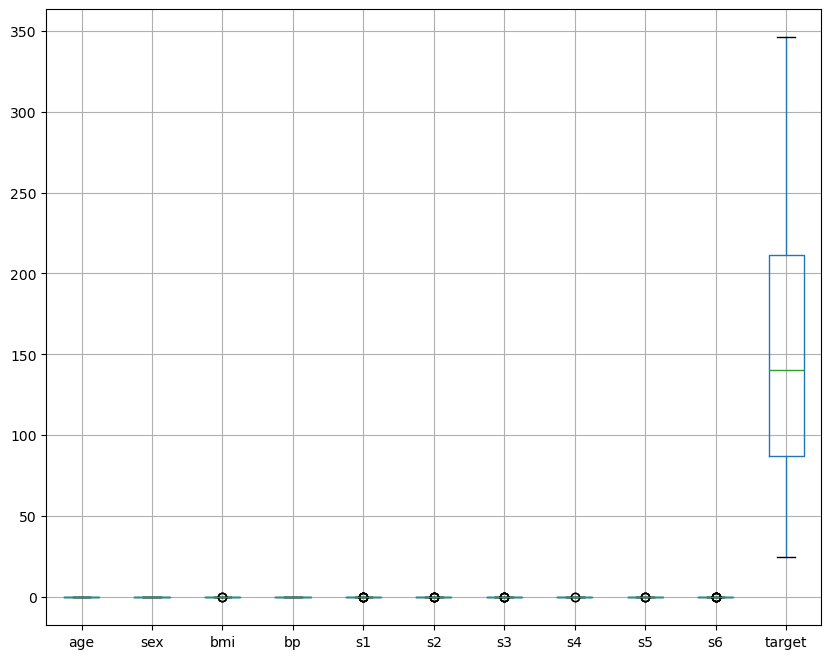

In [36]:
df.boxplot(figsize=(10,8))
plt.show()
